## Bacic Information

In [ ]:
# Import Part
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [16]:
# Load File
df_train = pd.read_csv('/Users/xlu/Desktop/DATA1030/Final Project/data/exports/players_2015_2024.csv')

df_train.head()

,season_end,Player,Age,Tm,GP,W,L,W_PCT,MP,FGM,...,AST%,TOV%,USG%,PER,WS,OWS,DWS,WS/48,BPM,VORP
0,2015,Quincy Acy,24.0,NYK,NaN,NaN,NaN,NaN,1287.0,NaN,...,0.087,0.138,0.155,11.9,1.7,1.0,0.7,0.063,-3.1,-0.3
1,2015,Jordan Adams,20.0,MEM,NaN,NaN,NaN,NaN,248.0,NaN,...,0.101,0.127,0.204,12.8,0.4,0.0,0.4,0.073,-0.6,0.1
2,2015,Steven Adams,21.0,OKC,NaN,NaN,NaN,NaN,1771.0,NaN,...,0.055,0.168,0.143,14.1,4.1,1.9,2.2,0.111,0.4,1.1
3,2015,Jeff Adrien,28.0,MIN,NaN,NaN,NaN,NaN,215.0,NaN,...,0.105,0.129,0.143,14.2,0.4,0.2,0.2,0.087,-2.2,0.0
4,2015,Arron Afflalo,29.0,DEN,NaN,NaN,NaN,NaN,1750.0,NaN,...,0.093,0.103,0.199,11.7,1.8,1.4,0.4,0.050,-1.6,0.2


In [17]:
print('data dimensions:',df_train.shape)
perc_missing_per_ftr = df_train.isnull().sum(axis=0)/df_train.shape[0]
print('fraction of missing values in features:')
print(perc_missing_per_ftr[perc_missing_per_ftr > 0])
print('data types of the features with missing values:')
print(df_train[perc_missing_per_ftr[perc_missing_per_ftr > 0].index].dtypes)
frac_missing = sum(df_train.isnull().sum(axis=1)!=0)/df_train.shape[0]
print('fraction of points with missing values:',frac_missing)

data dimensions: (5500, 39)
fraction of missing values in features:
GP       0.299091
W        0.299091
L        0.299091
W_PCT    0.299091
FGM      0.299091
FG3M     0.299091
FG3A     0.299091
FTM      0.299091
OREB     0.299091
DREB     0.299091
REB      0.299091
TS%      0.001273
3PAr     0.005818
FTr      0.005818
TOV%     0.702000
PER      0.700909
WS       0.700909
OWS      0.700909
DWS      0.700909
WS/48    0.700909
BPM      0.700909
VORP     0.700909
dtype: float64
data types of the features with missing values:
GP       float64
W        float64
L        float64
W_PCT    float64
FGM      float64
FG3M     float64
FG3A     float64
FTM      float64
OREB     float64
DREB     float64
REB      float64
TS%      float64
3PAr     float64
FTr      float64
TOV%     float64
PER      float64
WS       float64
OWS      float64
DWS      float64
WS/48    float64
BPM      float64
VORP     float64
dtype: object
fraction of points with missing values: 1.0


In [18]:
# Setting Features
# Target Variable 'y': High USG% (>= 0.25)
sd = 0.25
df_train['is_high_usg'] = (df_train['USG%'] >= sd).astype(int)

df_train = df_train.drop(columns = ['Tm', 'GP', 'W', 'L'])

y = df_train['is_high_usg']
X = df_train.loc[:, df_train.columns != 'is_high_usg']
X = X.drop(columns=["USG%"])

print(y)
print(X.head())

0       0
1       0
2       0
3       0
4       0
       ..
5495    0
5496    0
5497    0
5498    0
5499    1
Name: is_high_usg, Length: 5500, dtype: int64
   season_end         Player   Age  W_PCT      MP  FGM    FGA  FG3M  FG3A  \
0        2015     Quincy Acy  24.0    NaN  1287.0  NaN  331.0   NaN   NaN   
1        2015   Jordan Adams  20.0    NaN   248.0  NaN   86.0   NaN   NaN   
2        2015   Steven Adams  21.0    NaN  1771.0  NaN  399.0   NaN   NaN   
3        2015    Jeff Adrien  28.0    NaN   215.0  NaN   44.0   NaN   NaN   
4        2015  Arron Afflalo  29.0    NaN  1750.0  NaN  657.0   NaN   NaN   

   FTM  ...   TRB%   AST%   TOV%   PER   WS  OWS  DWS  WS/48  BPM  VORP  
0  NaN  ...  0.135  0.087  0.138  11.9  1.7  1.0  0.7  0.063 -3.1  -0.3  
1  NaN  ...  0.064  0.101  0.127  12.8  0.4  0.0  0.4  0.073 -0.6   0.1  
2  NaN  ...  0.158  0.055  0.168  14.1  4.1  1.9  2.2  0.111  0.4   1.1  
3  NaN  ...  0.205  0.105  0.129  14.2  0.4  0.2  0.2  0.087 -2.2   0.0  
4  NaN  ...

## Splitting

In [19]:
# Splitting Season with 60/20/20 style
season_col = "season_end"
s = pd.to_numeric(X[season_col], errors="coerce").astype(int)
g = pd.DataFrame({"y": y.values, "s": s}).groupby("s")["y"].agg(n="count", pos="sum").sort_index()

yrs  = g.index.to_numpy()
n_y  = g["n"].to_numpy()
p_y  = g["pos"].to_numpy()
cum_n, cum_p = np.cumsum(n_y), np.cumsum(p_y)
N, P = int(cum_n[-1]), int(cum_p[-1])
glob = float(P / N)

i1, i2 = np.searchsorted(cum_n, [0.60 * N, 0.80 * N])
I = range(max(0, i1 - 1),      min(len(yrs) - 2, i1 + 2))
J = range(max(i1 + 1, i2 - 1), min(len(yrs) - 1, i2 + 2))

best = None
for i in I:
    n_tr, p_tr = cum_n[i], cum_p[i]
    for j in J:
        n_va, p_va = cum_n[j] - cum_n[i], cum_p[j] - cum_p[i]
        n_te, p_te = N - cum_n[j],        P - cum_p[j]
        sizes = np.array([n_tr, n_va, n_te]) / N
        rates = np.array([
            p_tr / max(n_tr, 1),
            p_va / max(n_va, 1),
            p_te / max(n_te, 1),
        ])
        score = np.abs(rates - glob).sum() + 0.5 * np.abs(sizes - np.array([.6, .2, .2])).sum()
        if (best is None) or (score < best[0]):
            best = (score, yrs[i], yrs[j])

y_tr_end, y_va_end = int(best[1]), int(best[2])

idx_tr = s <= y_tr_end
idx_va = (s > y_tr_end) & (s <= y_va_end)
idx_te = s > y_va_end

X_train, y_train = X.loc[idx_tr], y.loc[idx_tr]
X_val,   y_val   = X.loc[idx_va], y.loc[idx_va]
X_test,  y_test  = X.loc[idx_te], y.loc[idx_te]

# Print out Splitted Results
print(f"Years → train: ≤{y_tr_end},  val: {y_tr_end+1}..{y_va_end},  test: >{y_va_end}")
print(np.unique(y_train, return_counts=True))
print(np.unique(y_val,   return_counts=True))
print(np.unique(y_test,  return_counts=True))

Years → train: ≤2020,  val: 2021..2022,  test: >2022
(array([0, 1]), array([2877,  367]))
(array([0, 1]), array([1025,  120]))
(array([0, 1]), array([979, 132]))


## Preprocessing

In [20]:
# collect the various features for Categorical and ordinal features
cat_ftrs = ['season_end', 'Player']
num_ftrs = [
    'Age','W_PCT','MP',
    'FGM','FGA','FG3M','FG3A','FTM','FTA',
    'OREB','DREB','REB','AST','STL','BLK','TOV','PTS',
    'TS%','3PAr','FTr','ORB%','DRB%','TRB%','AST%','TOV%',
    'PER','WS','OWS','DWS','WS/48','BPM','VORP'
]

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer

random_state = 42

# Categorical Feature Part
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Numerical Feature Part
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Collect to ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, cat_ftrs),
        ("num", numeric_transformer, num_ftrs),
    ],
    remainder="drop"
)

In [23]:
# fit + transform on train set
X_train_A = preprocessor.fit_transform(X_train)
feature_names = preprocessor.get_feature_names_out()
print("train:", X_train_A.shape)

# validation set
X_val_A = preprocessor.transform(X_val)
print("val:", X_val_A.shape)

# test set
X_test_A = preprocessor.transform(X_test)
print("test:", X_test_A.shape)

print("Number of features:", len(feature_names))
print(feature_names)

train: (3244, 1092)
val: (1145, 1092)
test: (1111, 1092)
Number of features: 1092
['cat__season_end_2015' 'cat__season_end_2016' 'cat__season_end_2017' ...
 'num__WS/48' 'num__BPM' 'num__VORP']


## Modeling Part

In [88]:
# Imports for modeling
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.model_selection import StratifiedKFold, GridSearchCV, ParameterGrid
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Baseline model: always predict high USG (class 1), ignore features
baseline = DummyClassifier(strategy="constant", constant=1)
baseline.fit(X_train_A, y_train)

y_tr_base = baseline.predict(X_train_A)
y_val_base = baseline.predict(X_val_A)
y_te_base = baseline.predict(X_test_A)

def get_scores(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
    }

print("Baseline (all high USG = 1):")
print(" train:", get_scores(y_train, y_tr_base))
print(" val: ", get_scores(y_val,   y_val_base))
print(" test: ", get_scores(y_test,  y_te_base))
print("Positive class ratio (is_high_usg=1):", y_train.mean())

Baseline (all high USG = 1):
 train: {'accuracy': 0.11313193588162762, 'f1': 0.20326779285516478, 'recall': 1.0, 'precision': 0.11313193588162762}
 val:  {'accuracy': 0.10480349344978165, 'f1': 0.18972332015810275, 'recall': 1.0, 'precision': 0.10480349344978165}
 test:  {'accuracy': 0.1188118811881188, 'f1': 0.21238938053097345, 'recall': 1.0, 'precision': 0.1188118811881188}
Positive class ratio (is_high_usg=1): 0.11313193588162762


In [89]:
#  Public Set
from sklearn.metrics import make_scorer

# Unified scoring
scoring = {
    "accuracy":  "accuracy",
    "f1":        make_scorer(f1_score, zero_division=0),
    "recall":    make_scorer(recall_score,   zero_division=0),
    "precision": make_scorer(precision_score,zero_division=0),
}

random_states = [0, 7, 25, 65, 300]

rows = []
add_baseline = True

In [90]:
# Logistic Regression
logreg_test_f1  = []
logreg_test_acc = []

param_grid = {"C": np.logspace(-3, 3, 7)}

for rs in random_states:
    print("=" * 60)
    print(f"[Logistic Regression] random_state = {rs}")

    best_f1_val  = -np.inf
    best_params  = None
    best_model   = None

    # Use validation sets to select hyperparameters
    for params in ParameterGrid(param_grid):
        est = LogisticRegression(
            max_iter=500,
            solver="liblinear",
            class_weight="balanced",
            random_state=rs,
            **params,
        )
        est.fit(X_train_A, y_train)
        y_val_pred = est.predict(X_val_A)
        f1_val = f1_score(y_val, y_val_pred, zero_division=0)

        if f1_val > best_f1_val:
            best_f1_val = f1_val
            best_params = params
            best_model  = est

    print(" best params (chosen on val):", best_params)
    print(f" best val F1 = {best_f1_val:.4f}")

    # Record train / val / test
    for split_name, X_split, y_split in [
        ("train", X_train_A, y_train),
        ("val",   X_val_A,   y_val),
        ("test",  X_test_A,  y_test),
    ]:
        y_pred = best_model.predict(X_split)
        s = get_scores(y_split, y_pred)
        print(
            f" [{split_name}] "
            f"acc={s['accuracy']:.3f}, "
            f"f1={s['f1']:.3f}, "
            f"recall={s['recall']:.3f}, "
            f"precision={s['precision']:.3f}"
        )
        rows.append({
            "model":        "Logistic Regression",
            "split":        split_name,
            "random_state": rs,
            **s
        })

    y_te_pred = best_model.predict(X_test_A)
    f1  = f1_score(y_test, y_te_pred, zero_division=0)
    acc = accuracy_score(y_test, y_te_pred)
    print(f" test F1 = {f1:.4f}")
    print(f" test ACC = {acc:.4f}")

    logreg_test_f1.append(f1)
    logreg_test_acc.append(acc)

print(
    "LogReg test F1 mean +/- std:",
    np.round(np.mean(logreg_test_f1), 4), "+/-",
    np.round(np.std(logreg_test_f1), 4)
)
print(
    "LogReg test ACC mean +/- std:",
    np.round(np.mean(logreg_test_acc), 4), "+/-",
    np.round(np.std(logreg_test_acc), 4)
)

[Logistic Regression] random_state = 0
 best params (chosen on val): {'C': np.float64(1.0)}
 best val F1 = 0.8340
 [train] acc=0.968, f1=0.874, recall=0.995, precision=0.780
 [val] acc=0.964, f1=0.834, recall=0.858, precision=0.811
 [test] acc=0.956, f1=0.822, recall=0.856, precision=0.790
 test F1 = 0.8218
 test ACC = 0.9559
[Logistic Regression] random_state = 7
 best params (chosen on val): {'C': np.float64(1.0)}
 best val F1 = 0.8340
 [train] acc=0.968, f1=0.874, recall=0.995, precision=0.780
 [val] acc=0.964, f1=0.834, recall=0.858, precision=0.811
 [test] acc=0.956, f1=0.822, recall=0.856, precision=0.790
 test F1 = 0.8218
 test ACC = 0.9559
[Logistic Regression] random_state = 25
 best params (chosen on val): {'C': np.float64(1.0)}
 best val F1 = 0.8340
 [train] acc=0.968, f1=0.874, recall=0.995, precision=0.780
 [val] acc=0.964, f1=0.834, recall=0.858, precision=0.811
 [test] acc=0.956, f1=0.822, recall=0.856, precision=0.790
 test F1 = 0.8218
 test ACC = 0.9559
[Logistic Regre

In [146]:
# Random Forest
rf_test_f1  = []
rf_test_acc = []

param_grid = {
    "n_estimators": [100, 200],
    "max_depth":    [3, 5, 10, None],
    "max_features": [0.3, 0.7, 1.0],
}

for rs in random_states:
    print("=" * 60)
    print(f"[Random Forest] random_state = {rs}")

    best_f1_val = -np.inf
    best_params = None
    best_model  = None

    for params in ParameterGrid(param_grid):
        est = RandomForestClassifier(
            n_jobs=-1,
            class_weight="balanced",
            random_state=rs,
            **params,
        )
        est.fit(X_train_A, y_train)
        y_val_pred = est.predict(X_val_A)
        f1_val = f1_score(y_val, y_val_pred, zero_division=0)

        if f1_val > best_f1_val:
            best_f1_val = f1_val
            best_params = params
            best_model  = est

    print(" best params (chosen on val):", best_params)
    print(f" best val F1 = {best_f1_val:.4f}")

    for split_name, X_split, y_split in [
        ("train", X_train_A, y_train),
        ("val",   X_val_A,   y_val),
        ("test",  X_test_A,  y_test),
    ]:
        y_pred = best_model.predict(X_split)
        s = get_scores(y_split, y_pred)
        print(
            f" [{split_name}] "
            f"acc={s['accuracy']:.3f}, "
            f"f1={s['f1']:.3f}, "
            f"recall={s['recall']:.3f}, "
            f"precision={s['precision']:.3f}"
        )
        rows.append({
            "model":        "Random Forest",
            "split":        split_name,
            "random_state": rs,
            **s
        })

    y_te_pred = best_model.predict(X_test_A)
    f1  = f1_score(y_test, y_te_pred, zero_division=0)
    acc = accuracy_score(y_test, y_te_pred)
    print(f" test F1 = {f1:.4f}")
    print(f" test ACC = {acc:.4f}")

    rf_test_f1.append(f1)
    rf_test_acc.append(acc)

print(
    "RF test F1 mean +/- std:",
    np.round(np.mean(rf_test_f1), 4), "+/-",
    np.round(np.std(rf_test_f1), 4)
)
print(
    "RF test ACC mean +/- std:",
    np.round(np.mean(rf_test_acc), 4), "+/-",
    np.round(np.std(rf_test_acc), 4)
)

[Random Forest] random_state = 0
 best params (chosen on val): {'max_depth': 10, 'max_features': 0.7, 'n_estimators': 200}
 best val F1 = 0.7593
 [train] acc=0.993, f1=0.969, recall=0.970, precision=0.967
 [val] acc=0.955, f1=0.759, recall=0.683, precision=0.854
 [test] acc=0.953, f1=0.794, recall=0.758, precision=0.833
 test F1 = 0.7937
 test ACC = 0.9532
[Random Forest] random_state = 7
 best params (chosen on val): {'max_depth': 10, 'max_features': 1.0, 'n_estimators': 100}
 best val F1 = 0.7558
 [train] acc=0.993, f1=0.967, recall=0.965, precision=0.970
 [val] acc=0.954, f1=0.756, recall=0.683, precision=0.845
 [test] acc=0.952, f1=0.792, recall=0.765, precision=0.821
 test F1 = 0.7922
 test ACC = 0.9523
[Random Forest] random_state = 25
 best params (chosen on val): {'max_depth': 5, 'max_features': 0.7, 'n_estimators': 200}
 best val F1 = 0.7686
 [train] acc=0.953, f1=0.805, recall=0.861, precision=0.756
 [val] acc=0.951, f1=0.769, recall=0.775, precision=0.762
 [test] acc=0.936, 

In [92]:
# Gradient Boosting
gb_test_f1  = []
gb_test_acc = []

param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3],
}

for rs in random_states:
    print("=" * 60)
    print(f"[Gradient Boosting] random_state = {rs}")

    best_f1_val = -np.inf
    best_params = None
    best_model  = None

    for params in ParameterGrid(param_grid):
        est = GradientBoostingClassifier(
            random_state=rs,
            **params,
        )
        est.fit(X_train_A, y_train)
        y_val_pred = est.predict(X_val_A)
        f1_val = f1_score(y_val, y_val_pred, zero_division=0)

        if f1_val > best_f1_val:
            best_f1_val = f1_val
            best_params = params
            best_model  = est

    print(" best params (chosen on val):", best_params)
    print(f" best val F1 = {best_f1_val:.4f}")

    for split_name, X_split, y_split in [
        ("train", X_train_A, y_train),
        ("val",   X_val_A,   y_val),
        ("test",  X_test_A,  y_test),
    ]:
        y_pred = best_model.predict(X_split)
        s = get_scores(y_split, y_pred)
        print(
            f" [{split_name}] "
            f"acc={s['accuracy']:.3f}, "
            f"f1={s['f1']:.3f}, "
            f"recall={s['recall']:.3f}, "
            f"precision={s['precision']:.3f}"
        )
        rows.append({
            "model":        "Gradient Boosting",
            "split":        split_name,
            "random_state": rs,
            **s
        })

    y_te_pred = best_model.predict(X_test_A)
    f1  = f1_score(y_test, y_te_pred, zero_division=0)
    acc = accuracy_score(y_test, y_te_pred)
    print(f" test F1 = {f1:.4f}")
    print(f" test ACC = {acc:.4f}")

    gb_test_f1.append(f1)
    gb_test_acc.append(acc)

print(
    "GB test F1 mean +/- std:",
    np.round(np.mean(gb_test_f1), 4), "+/-",
    np.round(np.std(gb_test_f1), 4)
)
print(
    "GB test ACC mean +/- std:",
    np.round(np.mean(gb_test_acc), 4), "+/-",
    np.round(np.std(gb_test_acc), 4)
)

[Gradient Boosting] random_state = 0
 best params (chosen on val): {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
 best val F1 = 0.7016
 [train] acc=0.977, f1=0.887, recall=0.801, precision=0.993
 [val] acc=0.950, f1=0.702, recall=0.558, precision=0.944
 [test] acc=0.945, f1=0.731, recall=0.629, precision=0.874
 test F1 = 0.7313
 test ACC = 0.9451
[Gradient Boosting] random_state = 7
 best params (chosen on val): {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
 best val F1 = 0.6952
 [train] acc=0.960, f1=0.789, recall=0.662, precision=0.976
 [val] acc=0.950, f1=0.695, recall=0.542, precision=0.970
 [test] acc=0.942, f1=0.712, recall=0.598, precision=0.878
 test F1 = 0.7117
 test ACC = 0.9424
[Gradient Boosting] random_state = 25
 best params (chosen on val): {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
 best val F1 = 0.7016
 [train] acc=0.977, f1=0.887, recall=0.801, precision=0.993
 [val] acc=0.950, f1=0.702, recall=0.558, precision=0.944
 [tes

In [93]:
# SVM (RBF)
svm_test_f1  = []
svm_test_acc = []

param_grid = {
    "C":     np.logspace(-1, 3, 5),
    "gamma": np.logspace(-3, 1, 5),
}

for rs in random_states:
    print("=" * 60)
    print(f"[SVM (RBF)] random_state = {rs}")

    best_f1_val = -np.inf
    best_params = None
    best_model  = None

    for params in ParameterGrid(param_grid):
        est = SVC(
            kernel="rbf",
            class_weight="balanced",
            probability=False,
            random_state=rs,
            **params,
        )
        est.fit(X_train_A, y_train)
        y_val_pred = est.predict(X_val_A)
        f1_val = f1_score(y_val, y_val_pred, zero_division=0)

        if f1_val > best_f1_val:
            best_f1_val = f1_val
            best_params = params
            best_model  = est

    print(" best params (chosen on val):", best_params)
    print(f" best val F1 = {best_f1_val:.4f}")

    for split_name, X_split, y_split in [
        ("train", X_train_A, y_train),
        ("val",   X_val_A,   y_val),
        ("test",  X_test_A,  y_test),
    ]:
        y_pred = best_model.predict(X_split)
        s = get_scores(y_split, y_pred)
        print(
            f" [{split_name}] "
            f"acc={s['accuracy']:.3f}, "
            f"f1={s['f1']:.3f}, "
            f"recall={s['recall']:.3f}, "
            f"precision={s['precision']:.3f}"
        )
        rows.append({
            "model":        "SVM (RBF)",
            "split":        split_name,
            "random_state": rs,
            **s
        })

    y_te_pred = best_model.predict(X_test_A)
    f1  = f1_score(y_test, y_te_pred, zero_division=0)
    acc = accuracy_score(y_test, y_te_pred)
    print(f" test F1 = {f1:.4f}")
    print(f" test ACC = {acc:.4f}")

    svm_test_f1.append(f1)
    svm_test_acc.append(acc)

print(
    "SVM test F1 mean +/- std:",
    np.round(np.mean(svm_test_f1), 4), "+/-",
    np.round(np.std(svm_test_f1), 4)
)
print(
    "SVM test ACC mean +/- std:",
    np.round(np.mean(svm_test_acc), 4), "+/-",
    np.round(np.std(svm_test_acc), 4)
)

[SVM (RBF)] random_state = 0
 best params (chosen on val): {'C': np.float64(100.0), 'gamma': np.float64(0.001)}
 best val F1 = 0.8250
 [train] acc=0.968, f1=0.875, recall=0.997, precision=0.779
 [val] acc=0.963, f1=0.825, recall=0.825, precision=0.825
 [test] acc=0.958, f1=0.817, recall=0.795, precision=0.840
 test F1 = 0.8171
 test ACC = 0.9577
[SVM (RBF)] random_state = 7
 best params (chosen on val): {'C': np.float64(100.0), 'gamma': np.float64(0.001)}
 best val F1 = 0.8250
 [train] acc=0.968, f1=0.875, recall=0.997, precision=0.779
 [val] acc=0.963, f1=0.825, recall=0.825, precision=0.825
 [test] acc=0.958, f1=0.817, recall=0.795, precision=0.840
 test F1 = 0.8171
 test ACC = 0.9577
[SVM (RBF)] random_state = 25
 best params (chosen on val): {'C': np.float64(100.0), 'gamma': np.float64(0.001)}
 best val F1 = 0.8250
 [train] acc=0.968, f1=0.875, recall=0.997, precision=0.779
 [val] acc=0.963, f1=0.825, recall=0.825, precision=0.825
 [test] acc=0.958, f1=0.817, recall=0.795, precisio

In [ ]:
# Summary table

results_df = pd.DataFrame(rows)

metrics = ["accuracy", "f1", "recall"]

summary = (
    results_df
    .groupby(["model", "split"])[metrics]
    .agg(["mean", "std"])
    .round(3)
)

summary

accuracy            f1        recall       
                              mean    std   mean    std   mean    std
model               split                                            
Gradient Boosting   test     0.944  0.002  0.722  0.015  0.612  0.024
                    train    0.968  0.012  0.835  0.074  0.730  0.102
                    val      0.950  0.000  0.697  0.007  0.548  0.015
Logistic Regression test     0.956  0.000  0.822  0.000  0.856  0.000
                    train    0.968  0.000  0.874  0.000  0.995  0.000
                    val      0.964  0.000  0.834  0.000  0.858  0.000
Random Forest       test     0.950  0.008  0.787  0.019  0.779  0.031
                    train    0.984  0.018  0.934  0.074  0.946  0.047
                    val      0.953  0.002  0.756  0.007  0.700  0.042
SVM (RBF)           test     0.958  0.000  0.817  0.000  0.795  0.000
                    train    0.968  0.000  0.875  0.000  0.997  0.000
                    val      0.963  0.000  0.825  0.000  0.825  0.000

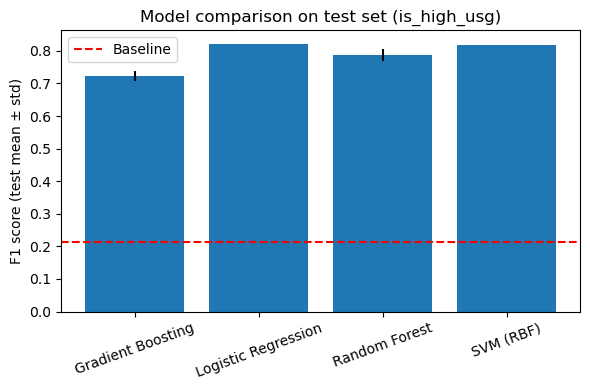

In [95]:
# Use macro F1 to calculate the baseline
baseline_scores_test = get_scores(y_test, y_te_base)
baseline_f1 = baseline_scores_test["f1"]

# Do groupby for four models
test_summary = (
    results_df[results_df["split"] == "test"]
    .groupby("model")["f1"]
    .agg(["mean", "std"])
    .reset_index()
)

plt.figure(figsize=(6, 4))
plt.bar(
    test_summary["model"],
    test_summary["mean"],
    yerr=test_summary["std"]
)

# Draw Horizontal Dashed Line as Baseline
plt.axhline(
    y=baseline_f1,
    linestyle="--",
    linewidth=1.5,
    color="red",
    label="Baseline"
)

plt.ylabel("F1 score (test mean ± std)")
plt.xticks(rotation=20)
plt.title("Model comparison on test set (is_high_usg)")
plt.legend()
plt.tight_layout()
plt.show()

## CV

In [131]:
# Import Part
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier

In [147]:
# Decision Tree Part (with time-series CV)
dt_test_f1  = []
dt_test_acc = []

for rs in random_states:
    print("=" * 60)
    print(f"[Decision Tree] random_state = {rs}")

    # Time-series CV
    cv = TimeSeriesSplit(n_splits=5)

    est = DecisionTreeClassifier(
        random_state=rs,
        class_weight="balanced"
    )

    param_grid = {
        "max_depth": [3, 5, 7, 9, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    }

    grid = GridSearchCV(
        estimator=est,
        param_grid=param_grid,
        scoring=scoring,
        refit="f1",
        cv=cv,
        n_jobs=-1,
        return_train_score=True
    )

    # CV is done only on the training period (time-ordered)
    grid.fit(X_train_A, y_train)

    print("best params:", grid.best_params_)
    print("best cv f1:",  grid.best_score_)

    # Evaluate on the held-out test set
    y_test_pred = grid.predict(X_test_A)
    cur_f1  = f1_score(y_test, y_test_pred, zero_division=0)
    cur_acc = accuracy_score(y_test, y_test_pred)

    print(f"test F1  = {cur_f1:.4f}")
    print(f"test ACC = {cur_acc:.4f}")

    dt_test_f1.append(cur_f1)
    dt_test_acc.append(cur_acc)

[Decision Tree] random_state = 0
best params: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10}
best cv f1: 0.5387141595490742
test F1  = 0.6257
test ACC = 0.8848
[Decision Tree] random_state = 7
best params: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
best cv f1: 0.52374407556728
test F1  = 0.6213
test ACC = 0.8848
[Decision Tree] random_state = 25
best params: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10}
best cv f1: 0.5351616864171937
test F1  = 0.6257
test ACC = 0.8848
[Decision Tree] random_state = 65
best params: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
best cv f1: 0.531801613919725
test F1  = 0.6440
test ACC = 0.8965
[Decision Tree] random_state = 300
best params: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
best cv f1: 0.5237564320853433
test F1  = 0.6213
test ACC = 0.8848


In [ ]:
# Random Forest (time-series CV version)
rf_test_f1  = []
rf_test_acc = []

for rs in random_states:
    print("=" * 60)
    print(f"[Random Forest] random_state = {rs}")

    # Time-series CV
    cv = TimeSeriesSplit(n_splits=5)

    est = RandomForestClassifier(
        random_state=rs,
        class_weight="balanced",
        n_jobs=-1
    )

    param_grid = {
        "n_estimators": [100, 200],
        "max_depth": [5, 10, None],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2],
        "max_features": ["sqrt", "log2"]
    }

    grid = GridSearchCV(
        estimator=est,
        param_grid=param_grid,
        scoring=scoring,
        refit="f1",
        cv=cv,
        n_jobs=-1,
        return_train_score=True
    )

    grid.fit(X_train_A, y_train)

    print("best params:", grid.best_params_)
    print("best cv f1:",  grid.best_score_)

    # Calculate test set
    y_test_pred = grid.predict(X_test_A)
    cur_f1  = f1_score(y_test, y_test_pred, zero_division=0)
    cur_acc = accuracy_score(y_test, y_test_pred)

    print(f"test F1  = {cur_f1:.4f}")
    print(f"test ACC = {cur_acc:.4f}")

    rf_test_f1.append(cur_f1)
    rf_test_acc.append(cur_acc)

[Random Forest] random_state = 0
best params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
best cv f1: 0.6098976706028315
test F1  = 0.6879
test ACC = 0.9208
[Random Forest] random_state = 7
best params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
best cv f1: 0.6085125570263787
test F1  = 0.6950
test ACC = 0.9226
[Random Forest] random_state = 25
best params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
best cv f1: 0.6080100066081374
test F1  = 0.6894
test ACC = 0.9181
[Random Forest] random_state = 65
best params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
best cv f1: 0.6065101503443622
test F1  = 0.6926
test ACC = 0.9217
[Random Forest] random_state = 300
best params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_lea

In [135]:
print("LogReg F1 mean/std:", np.mean(logreg_test_f1), np.std(logreg_test_f1))
print("DT     F1 mean/std:", np.mean(dt_test_f1),      np.std(dt_test_f1))
print("RF     F1 mean/std:", np.mean(rf_test_f1),      np.std(rf_test_f1))

LogReg F1 mean/std: 0.8218181818181819 1.1102230246251565e-16
DT     F1 mean/std: 0.627605677379433 0.008415037510650774
RF     F1 mean/std: 0.6906300133874408 0.0027543915666289583


## Metrics

In [148]:
# Metrics
# 1. Collect baseline scores into a DataFrame
baseline_rows = []
for split_name, y_true, y_pred in [
    ("train", y_train, y_tr_base),
    ("val",   y_val,   y_val_base),
    ("test",  y_test,  y_te_base),
]:
    s = get_scores(y_true, y_pred)
    baseline_rows.append({
        "model": "Baseline (Minority class)",
        "split": split_name,
        **s,
    })

baseline_df = pd.DataFrame(baseline_rows)

# 2. Concatenate baseline with the other models
results_with_baseline = pd.concat(
    [results_df, baseline_df],
    ignore_index=True
)

# 3. Show test results
metrics = ["accuracy", "f1", "recall"]

test_summary = (
    results_with_baseline[results_with_baseline["split"] == "test"]
    .groupby("model")[metrics]
    .agg(["mean", "std"])
    .round(3)
)

test_summary

accuracy            f1        recall       
                              mean    std   mean    std   mean    std
model                                                                
Baseline (Minority class)    0.119    NaN  0.212    NaN  1.000    NaN
Gradient Boosting            0.944  0.002  0.722  0.015  0.612  0.024
Logistic Regression          0.956  0.000  0.822  0.000  0.856  0.000
Random Forest                0.950  0.008  0.787  0.019  0.779  0.031
SVM (RBF)                    0.958  0.000  0.817  0.000  0.795  0.000

In [149]:
# 4. Compare F1 scores against the baseline on the test set
base_f1 = test_summary.loc["Baseline (Minority class)", ("f1", "mean")]

comp = pd.DataFrame({
    "f1_mean":     test_summary[("f1", "mean")],
    "f1_std":      test_summary[("f1", "std")],
    "acc_mean":    test_summary[("accuracy", "mean")],
    "acc_std":     test_summary[("accuracy", "std")],
    "recall_mean": test_summary[("recall", "mean")],
    "recall_std":  test_summary[("recall", "std")],
})

# Absolute improvement in F1 over the baseline
comp["f1_improvement_vs_baseline"] = comp["f1_mean"] - base_f1

# z-score of F1 improvement (difference divided by model's std)
comp["f1_z_vs_baseline"] = (
    comp["f1_improvement_vs_baseline"] /
    comp["f1_std"].replace(0, np.nan)
)

comp.sort_values("f1_mean", ascending=False)

,f1_mean,f1_std,acc_mean,acc_std,recall_mean,recall_std,f1_improvement_vs_baseline,f1_z_vs_baseline
model,,,,,,,,
Logistic Regression,0.822,0.000,0.956,0.000,0.856,0.000,0.610,NaN
SVM (RBF),0.817,0.000,0.958,0.000,0.795,0.000,0.605,NaN
Random Forest,0.787,0.019,0.950,0.008,0.779,0.031,0.575,30.263158
Gradient Boosting,0.722,0.015,0.944,0.002,0.612,0.024,0.510,34.000000
Baseline (Minority class),0.212,NaN,0.119,NaN,1.000,NaN,0.000,NaN


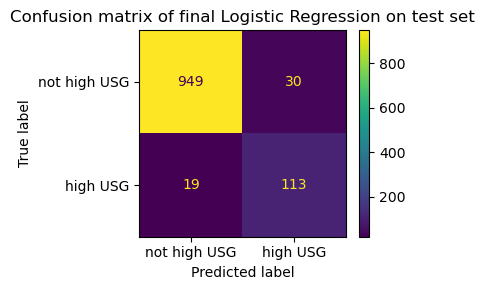

              precision    recall  f1-score   support

not high USG      0.980     0.969     0.975       979
    high USG      0.790     0.856     0.822       132

    accuracy                          0.956      1111
   macro avg      0.885     0.913     0.898      1111
weighted avg      0.958     0.956     0.957      1111



In [ ]:
# Final Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
import matplotlib.pyplot as plt

final_logreg = LogisticRegression(
    max_iter=500,
    solver="liblinear",
    class_weight="balanced",
    C=1.0,
    random_state=0
)

final_logreg.fit(X_train_A, y_train)

y_test_pred_final = final_logreg.predict(X_test_A)

# 1. Confusion matrix
cm = confusion_matrix(y_test, y_test_pred_final)

disp = ConfusionMatrixDisplay(
    cm,
    display_labels=["not high USG", "high USG"]
)

fig, ax = plt.subplots(figsize=(4, 3))
disp.plot(ax=ax)
plt.title("Confusion matrix of final Logistic Regression on test set")
plt.tight_layout()
plt.show()

# 2. Detailed precision / recall / f1 report (per class + macro/weighted)
print(classification_report(
    y_test,
    y_test_pred_final,
    target_names=["not high USG", "high USG"],
    digits=3
))

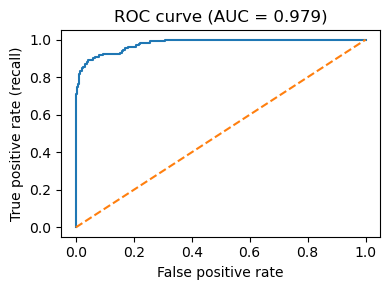

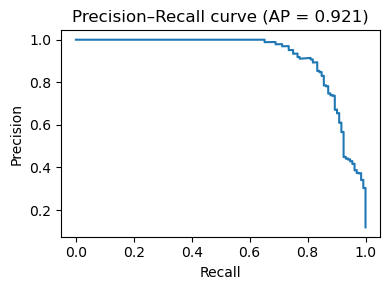

In [ ]:
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)

test_scores = final_logreg.decision_function(X_test_A)

# 1. ROC + AUC
fpr, tpr, _ = roc_curve(y_test, test_scores)
roc_auc = roc_auc_score(y_test, test_scores)

plt.figure(figsize=(4, 3))
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate (recall)")
plt.title(f"ROC curve (AUC = {roc_auc:.3f})")
plt.tight_layout()
plt.show()

# 2. Precision–Recall + AP (AUC of PR curve)
precision, recall, _ = precision_recall_curve(y_test, test_scores)
ap = average_precision_score(y_test, test_scores)

plt.figure(figsize=(4, 3))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision–Recall curve (AP = {ap:.3f})")
plt.tight_layout()
plt.show()

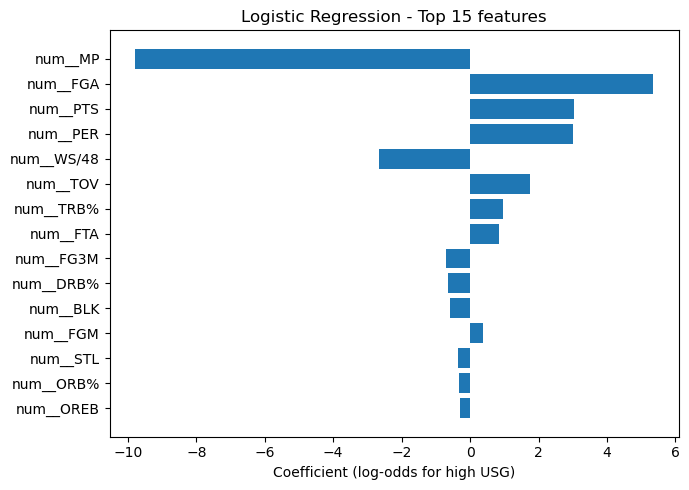

In [139]:
# Top-15 features by |coefficient|
logreg_final = LogisticRegression(
    max_iter=500,
    solver="liblinear",
    class_weight="balanced",
    C=1.0,
    random_state=0
)
logreg_final.fit(X_train_A, y_train)

coefs = logreg_final.coef_[0]

coef_df = (
    pd.DataFrame({
        "feature": feature_names,
        "coef": coefs,
        "abs_coef": np.abs(coefs)
    })
    .sort_values("abs_coef", ascending=False)
)

coef_num = (
    coef_df[coef_df["feature"].str.startswith("num__")]
    .sort_values("abs_coef", ascending=False)
)

top_n = 15
top_coef = coef_num.head(top_n)

plt.figure(figsize=(7, 5))
plt.barh(top_coef["feature"][::-1], top_coef["coef"][::-1])
plt.xlabel("Coefficient (log-odds for high USG)")
plt.title("Logistic Regression - Top 15 features")
plt.tight_layout()
plt.savefig("logreg_coef_top15.png", dpi=300)
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Final Random Forest
rf_final = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    max_features=1.0,
    random_state=0,
    n_jobs=-1
)

rf_final.fit(X_train_A, y_train)

# Feature Names
feature_names = preprocessor.get_feature_names_out()

# Take Gini Importance from Final RandomForest Model
rf_importances = rf_final.feature_importances_

print("len(feature_names):", len(feature_names))
print("len(rf_importances):", len(rf_importances))

# Create Dataframe and Sort importance from highest to lowest
rf_imp_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": rf_importances
    })
    .sort_values("importance", ascending=False)
)

rf_imp_df.head(20)

len(feature_names): 1092
len(rf_importances): 1092


,feature,importance
1076,num__PTS,0.316422
1064,num__FGA,0.137351
1062,num__MP,0.082561
1085,num__PER,0.053522
1083,num__AST%,0.050962
1089,num__WS/48,0.033707
1077,num__TS%,0.017666
1075,num__TOV,0.014896
1068,num__FTA,0.013767
1080,num__ORB%,0.013644


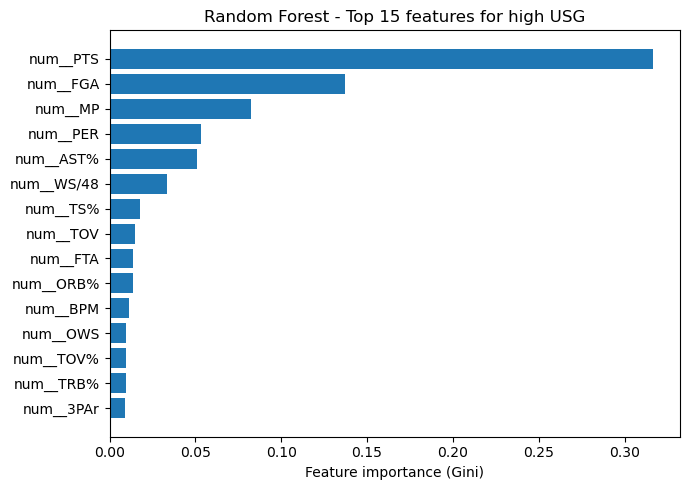

In [141]:
# RF – Top 15 features
top_n = 15
top_rf = rf_imp_df.head(top_n)

plt.figure(figsize=(7, 5))
plt.barh(top_rf["feature"][::-1], top_rf["importance"][::-1])
plt.xlabel("Feature importance (Gini)")
plt.title("Random Forest - Top 15 features for high USG")
plt.tight_layout()
plt.savefig("rf_feature_importance_top15.png", dpi=300)
plt.show()

In [ ]:
# Final Gradient Boosting
gb_final = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=0
)

gb_final.fit(X_train_A, y_train)

gb_imp = gb_final.feature_importances_
gb_imp_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": gb_imp
    })
    .sort_values("importance", ascending=False)
)

gb_imp_df.head(20)

,feature,importance
1076,num__PTS,0.230628
1064,num__FGA,0.224596
1062,num__MP,0.105075
1085,num__PER,0.055303
1083,num__AST%,0.053930
1089,num__WS/48,0.050467
1068,num__FTA,0.018601
1080,num__ORB%,0.014116
1077,num__TS%,0.010054
1073,num__STL,0.009738


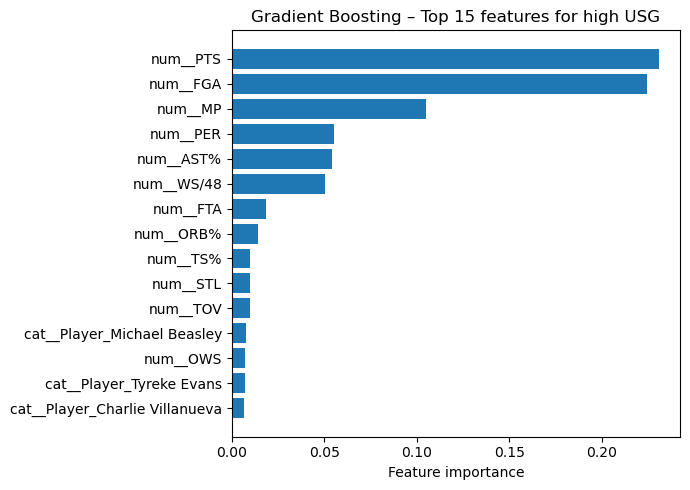

In [ ]:
# GB – Top 15 features
top_n = 15
top_gb = gb_imp_df.head(top_n)

plt.figure(figsize=(7, 5))
plt.barh(top_gb["feature"][::-1], top_gb["importance"][::-1])
plt.xlabel("Feature importance")
plt.title("Gradient Boosting - Top 15 features for high USG")
plt.tight_layout()
plt.savefig("gb_feature_importance_top15.png", dpi=300)
plt.show()

In [ ]:
from sklearn.inspection import permutation_importance

# Permutation importance
if hasattr(X_test_A, "toarray"):
    X_test_perm = X_test_A.toarray()
else:
    X_test_perm = X_test_A

# Permutation importance for final
perm_result = permutation_importance(
    final_logreg,
    X_test_perm,
    y_test,
    n_repeats=10,
    random_state=0,
    n_jobs=-1,
    scoring="f1"
)

perm_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance_mean": perm_result.importances_mean,
        "importance_std": perm_result.importances_std
    })
    .sort_values("importance_mean", ascending=False)
)

perm_df.head(20)

,feature,importance_mean,importance_std
1064,num__FGA,0.670425,0.015852
1076,num__PTS,0.587464,0.021067
1062,num__MP,0.452593,0.006415
1075,num__TOV,0.358338,0.012502
1068,num__FTA,0.150824,0.013225
1082,num__TRB%,0.123426,0.015579
1063,num__FGM,0.088407,0.013293
1065,num__FG3M,0.057958,0.012209
1081,num__DRB%,0.050290,0.011495
1070,num__DREB,0.017295,0.007192


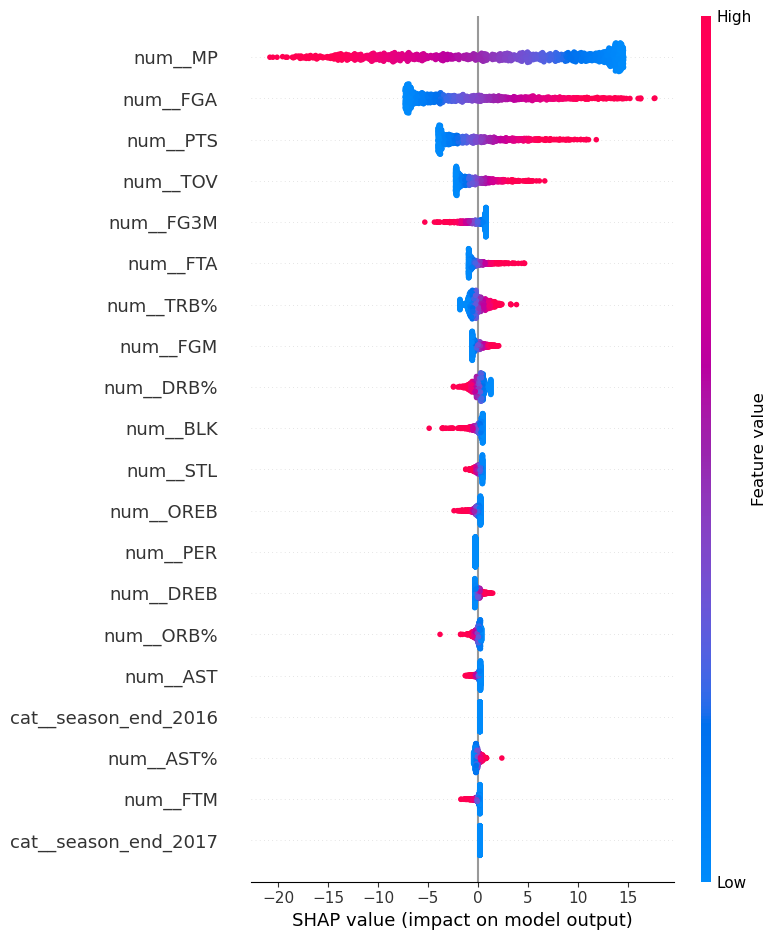

In [ ]:
import shap

shap.initjs()

if hasattr(X_train_A, "toarray"):
    X_train_dense = X_train_A.toarray()
    X_test_dense  = X_test_A.toarray()
else:
    X_train_dense = X_train_A
    X_test_dense  = X_test_A

feature_names = preprocessor.get_feature_names_out()

# Use LinearExplainer for Logistic Regression
explainer = shap.LinearExplainer(final_logreg, X_train_dense)
shap_values = explainer.shap_values(X_test_dense)

# Summary plot (TOP 20)
shap.summary_plot(
    shap_values,
    X_test_dense,
    feature_names=feature_names,
    max_display=20
)